#Swiggy Sales Analysis

### Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px #for creating interactive charts with filters, professional dashboards, etc

### import data

In [3]:
df = pd.read_excel('swiggy_data.xlsx')

In [4]:
df.head()

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
0,Karnataka,Bengaluru,2025-06-29,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0
1,Karnataka,Bengaluru,2025-04-03,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25
2,Karnataka,Bengaluru,2025-01-15,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48
3,Karnataka,Bengaluru,2025-04-17,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65
4,Karnataka,Bengaluru,2025-03-13,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,4.0,0


### metadata

In [5]:
print("No. of rows: ", df.shape[0])

No. of rows:  197430


In [6]:
print("No. of columns: ", df.shape[1])

No. of columns:  10


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197430 entries, 0 to 197429
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   State            197430 non-null  object        
 1   City             197430 non-null  object        
 2   Order Date       197430 non-null  datetime64[ns]
 3   Restaurant Name  197430 non-null  object        
 4   Location         197430 non-null  object        
 5   Category         197430 non-null  object        
 6   Dish Name        197430 non-null  object        
 7   Price (INR)      197430 non-null  float64       
 8   Rating           197430 non-null  float64       
 9   Rating Count     197430 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(1), object(6)
memory usage: 15.1+ MB


In [8]:
df.describe()

,Order Date,Price (INR),Rating,Rating Count
count,197430,197430.000000,197430.000000,197430.000000
mean,2025-05-01 19:41:20.996808960,268.512920,4.341582,28.321805
min,2025-01-01 00:00:00,0.950000,1.500000,0.000000
25%,2025-03-01 00:00:00,139.000000,4.300000,0.000000
50%,2025-05-02 00:00:00,229.000000,4.400000,2.000000
75%,2025-07-01 00:00:00,329.000000,4.500000,15.000000
max,2025-08-31 00:00:00,8000.000000,5.000000,999.000000
std,NaN,219.338363,0.422585,87.542593


#KPIs

## Total Sales

In [9]:
total_sales = df['Price (INR)'].sum()
print("Total Sales (INR): ", round(total_sales, 2))

Total Sales (INR):  53012505.77


## Average Rating

In [10]:
avg_rating = df['Rating'].mean()
print("Average Rating: ", round(avg_rating, 2))

Average Rating:  4.34


## Average Order Value

In [11]:
aov = df['Price (INR)'].mean()
print("Average Order Value: ", round(aov, 2))

Average Order Value:  268.51


## Ratings Count

In [12]:
ratings_count = df['Rating Count'].sum()
print("Ratings Count: ", ratings_count)

Ratings Count:  5591574


## Total Orders

In [13]:
total_orders = len(df)
print("Total Orders: ", round(total_orders, 2))

Total Orders:  197430


# Charts

## Monthly Sales Trend

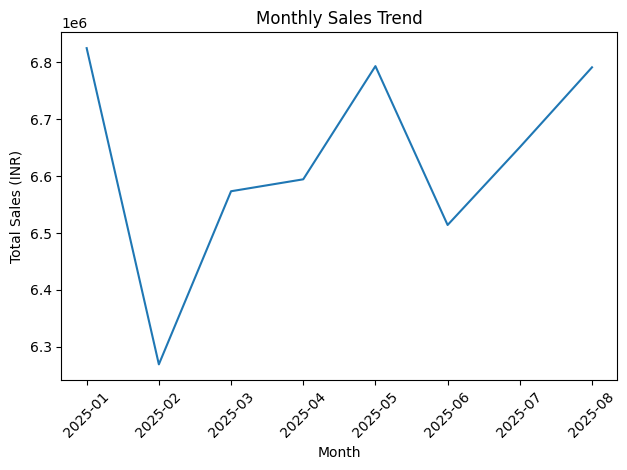

In [14]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

df["YearMonth"] = df["Order Date"].dt.to_period("M").astype(str)

monthly_sales = df.groupby("YearMonth")["Price (INR)"].sum().reset_index()

plt.figure()
plt.plot(monthly_sales["YearMonth"], monthly_sales["Price (INR)"])
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Total Sales (INR)")
plt.title("Monthly Sales Trend")
plt.tight_layout()
plt.show()


## Daily Sales Trend

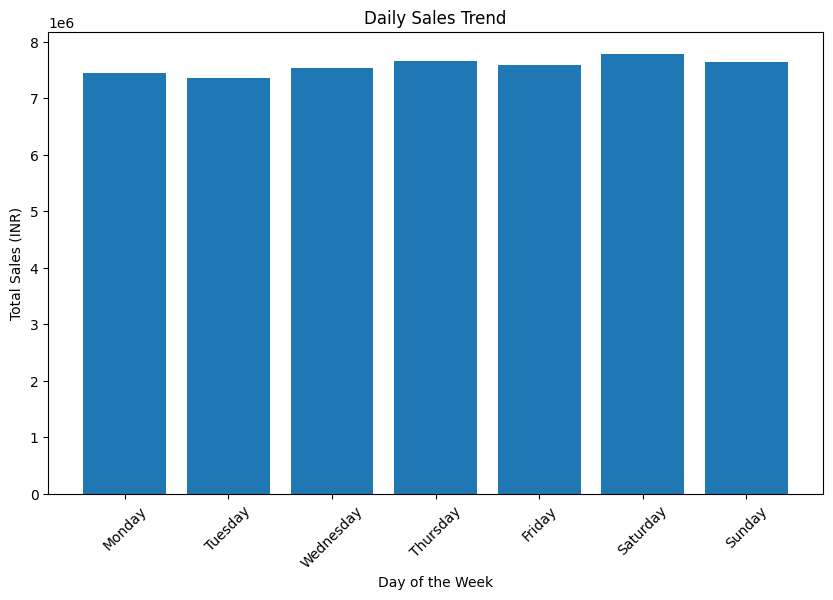

In [15]:
df["DayName"] = pd.to_datetime(df["Order Date"]).dt.day_name()

daily_sales = df.groupby("DayName")["Price (INR)"].sum().reindex(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])

plt.figure(figsize=(10, 6))
plt.bar(daily_sales.index, daily_sales.values)
plt.title("Daily Sales Trend")
plt.xlabel("Day of the Week")
plt.ylabel("Total Sales (INR)")
plt.xticks(rotation=45)
plt.show()

# Total Sales By Food Type (Veg vs Non Veg)

## Keywords

In [16]:
non_veg_keywords = ["chicken", "egg", "mutton", "fish", "prawn", "biryani", "kabab", "kebab", "non-veg", "non veg"]

df["Food Category"] = np.where(df["Dish Name"].str.lower().str.contains("|".join(non_veg_keywords), na=False), "Non-Veg", "Veg")

In [17]:
food_revenue = (df.groupby("Food Category")["Price (INR)"].sum().reset_index())

In [18]:
fig = px.pie(food_revenue, values="Price (INR)", names="Food Category", hole=0.5, title="Revenue Contribution: Veg vs Non-Veg")
fig.update_traces(textinfo="percent+label", pull=[0.05, 0])
fig.update_layout(height = 500, margin=dict(t=60, b=40, l=40, r=40))
fig.show()

## Total Sales by State

In [19]:
fig = px.bar(
    df.groupby("State", as_index=False)["Price (INR)"].sum().sort_values("Price (INR)", ascending=False),
    x="Price (INR)",
    y="State",
    orientation="h",
    title="Total Sales by State",
    labels={"Price (INR)": "Total Sales (INR)"},
)

fig.update_layout(height = 600, yaxis = dict(autorange="reversed"))
fig.show()

## Quarterly Performance Summary

In [31]:
df["Order_Date"] = pd.to_datetime(df["Order Date"])
df["Quarter"] = df["Order Date"].dt.to_period("Q").astype(str)

quarterly_summary=(
    df.groupby("Quarter", as_index=False)
    .agg(
        total_sales = ("Price (INR)", "sum"),
        total_orders = ("Order Date", "count"),
        avg_rating = ("Rating", "mean")
    ).sort_values("Quarter")
)
quarterly_summary["Total Sales"] = quarterly_summary["total_sales"].round(0)
quarterly_summary["Average_Rating"] = quarterly_summary["avg_rating"].round(2)
quarterly_summary

,Quarter,total_sales,total_orders,avg_rating,Total Sales,Average_Rating
0,2025Q1,19667821.77,73096,4.342643,19667822.0,4.34
1,2025Q2,19902256.59,74163,4.340011,19902257.0,4.34
2,2025Q3,13442427.41,50171,4.342359,13442427.0,4.34


##Top 5 Cities by Sales

In [40]:
top_5_cities = (
     df.groupby("City")["Price (INR)"].sum().nlargest(5).sort_values().reset_index()
)

fig = px.bar(
   top_5_cities,
   x="Price (INR)",
   y="City",
   orientation="h",
   title="Top 5 Cities by Sales"
)

fig.show()

## Weekly Trend Analysis

In [47]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["DayName"] = pd.to_datetime(df["Order Date"]).dt.day_name()

daily_sales = df.groupby("DayName")["Price (INR)"].sum().reindex(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])

fig = px.line(
    daily_sales,
    x=daily_sales.index,
    y=daily_sales.values,
    title="Weekly Trend Analysis",
    labels={"x": "Day of the Week", "y": "Total Sales (INR)"}
)
fig.show()